In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

In [2]:
base_dir = "/kaggle/input/cervical-cancer-largest-dataset-sipakmed"
categories = ["im_Dyskeratotic", "im_Koilocytotic", "im_Metaplastic", 
              "im_Parabasal", "im_Superficial-Intermediate"]

print("Base directory:", base_dir)
print("Categories:", categories)

Base directory: /kaggle/input/cervical-cancer-largest-dataset-sipakmed
Categories: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']


In [3]:
image_counts = {}

for category in categories:
    category_path = os.path.join(base_dir, category, category, "CROPPED")
    image_counts[category] = len([f for f in os.listdir(category_path) 
                                  if f.endswith(('.bmp', '.jpg', '.png'))])

print(image_counts)
print("\nTotal images:", sum(image_counts.values()))

{'im_Dyskeratotic': 813, 'im_Koilocytotic': 825, 'im_Metaplastic': 793, 'im_Parabasal': 787, 'im_Superficial-Intermediate': 831}

Total images: 4049


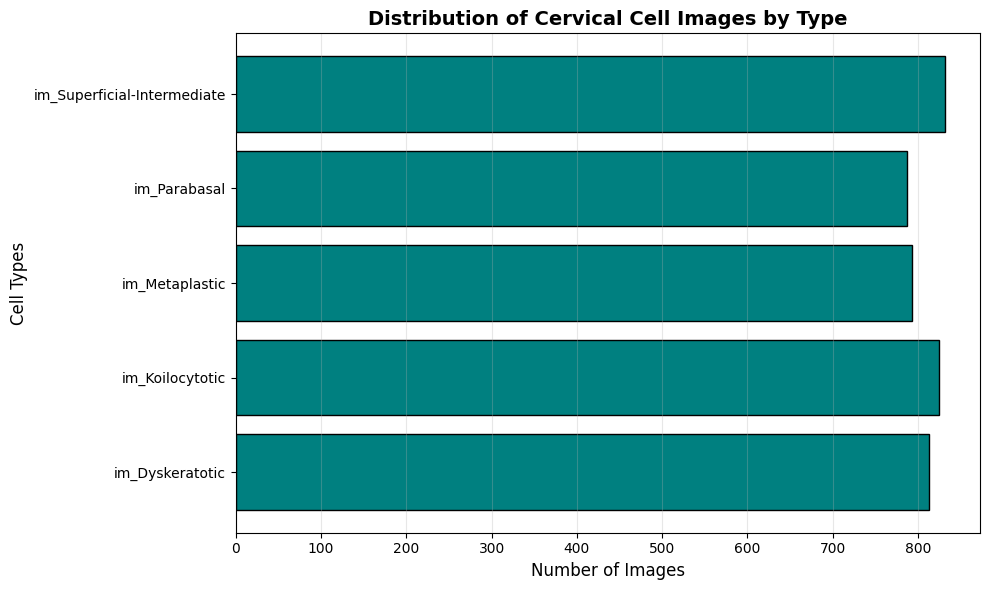

In [5]:
plt.figure(figsize=(10, 6))
plt.barh(list(image_counts.keys()), list(image_counts.values()), color='teal', edgecolor='black')
plt.title('Distribution of Cervical Cell Images by Type', fontsize=14, fontweight='bold')
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Cell Types', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
data = []

for category in categories:
    category_path = os.path.join(base_dir, category, category, "CROPPED")
    image_files = [f for f in os.listdir(category_path) if f.endswith(('.bmp', '.jpg', '.png'))]
    
    for image_file in image_files:
        img_path = os.path.join(category_path, image_file)
        data.append({'image_path': img_path, 'label': category})

df = pd.DataFrame(data)
print("DataFrame created with shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())

DataFrame created with shape: (4049, 2)

First 5 rows:
                                          image_path            label
0  /kaggle/input/cervical-cancer-largest-dataset-...  im_Dyskeratotic
1  /kaggle/input/cervical-cancer-largest-dataset-...  im_Dyskeratotic
2  /kaggle/input/cervical-cancer-largest-dataset-...  im_Dyskeratotic
3  /kaggle/input/cervical-cancer-largest-dataset-...  im_Dyskeratotic
4  /kaggle/input/cervical-cancer-largest-dataset-...  im_Dyskeratotic

Last 5 rows:
                                             image_path  \
4044  /kaggle/input/cervical-cancer-largest-dataset-...   
4045  /kaggle/input/cervical-cancer-largest-dataset-...   
4046  /kaggle/input/cervical-cancer-largest-dataset-...   
4047  /kaggle/input/cervical-cancer-largest-dataset-...   
4048  /kaggle/input/cervical-cancer-largest-dataset-...   

                            label  
4044  im_Superficial-Intermediate  
4045  im_Superficial-Intermediate  
4046  im_Superficial-Intermediate  
4047  im_Sup

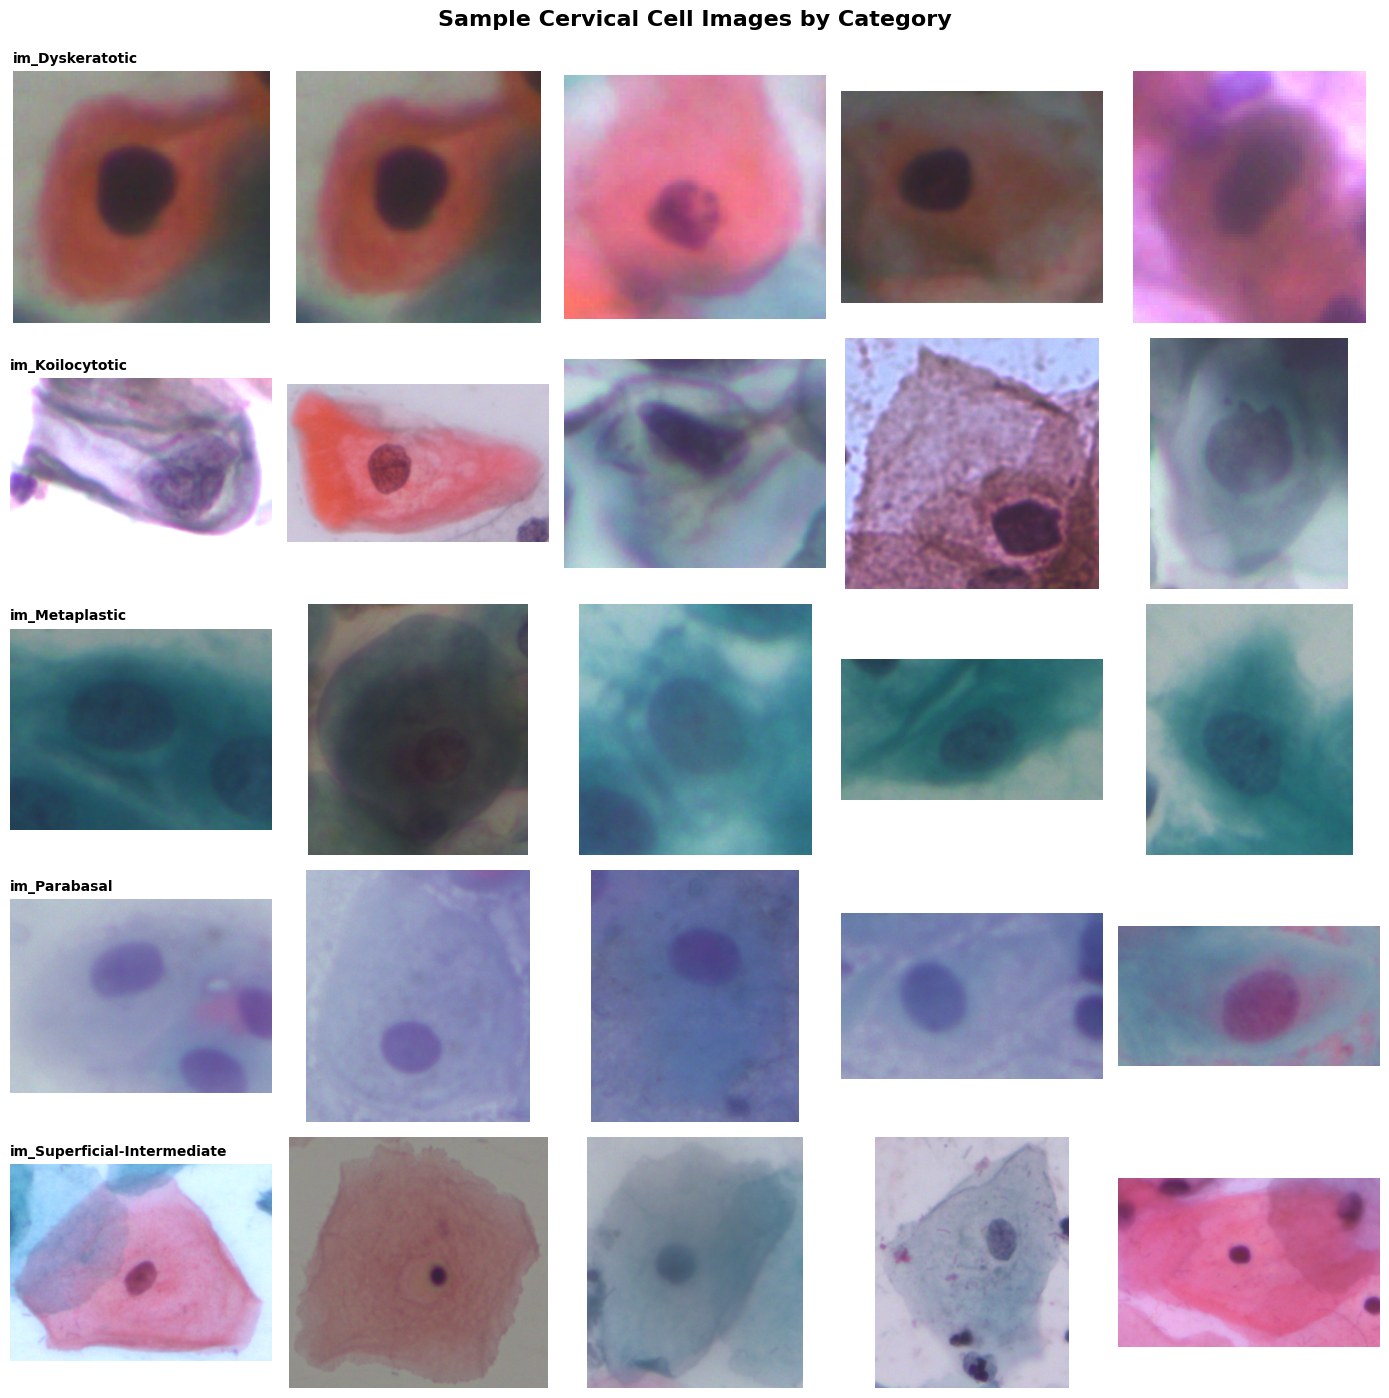

In [7]:
fig, axes = plt.subplots(5, 5, figsize=(14, 14))
fig.suptitle('Sample Cervical Cell Images by Category', fontsize=16, fontweight='bold', y=0.995)

for i, category in enumerate(categories):
    category_path = os.path.join(base_dir, category, category, "CROPPED")
    image_files = [f for f in os.listdir(category_path) if f.endswith(('.bmp', '.jpg', '.png'))]
    
    for j in range(5):
        img_path = os.path.join(category_path, image_files[j])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        axes[i, j].imshow(image)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(category, fontsize=10, loc='left', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
print("Class distribution before balancing:")
print(df['label'].value_counts().sort_index())
print("\nClass distribution percentages:")
print(df['label'].value_counts(normalize=True).sort_index() * 100)

Class distribution before balancing:
label
im_Dyskeratotic                813
im_Koilocytotic                825
im_Metaplastic                 793
im_Parabasal                   787
im_Superficial-Intermediate    831
Name: count, dtype: int64

Class distribution percentages:
label
im_Dyskeratotic                20.079032
im_Koilocytotic                20.375401
im_Metaplastic                 19.585083
im_Parabasal                   19.436898
im_Superficial-Intermediate    20.523586
Name: proportion, dtype: float64


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

base_dir = "/kaggle/input/cervical-cancer-largest-dataset-sipakmed"
categories = ["im_Dyskeratotic", "im_Koilocytotic", "im_Metaplastic", 
              "im_Parabasal", "im_Superficial-Intermediate"]

data = []
for category in categories:
    category_path = os.path.join(base_dir, category, category, "CROPPED")
    image_files = [f for f in os.listdir(category_path) if f.endswith(('.bmp', '.jpg', '.png'))]
    for image_file in image_files:
        img_path = os.path.join(category_path, image_file)
        data.append({'image_path': img_path, 'label': category})

df = pd.DataFrame(data)
print("DataFrame shape:", df.shape)
print(df.head())

DataFrame shape: (4049, 2)
                                          image_path            label
0  /kaggle/input/cervical-cancer-largest-dataset-...  im_Dyskeratotic
1  /kaggle/input/cervical-cancer-largest-dataset-...  im_Dyskeratotic
2  /kaggle/input/cervical-cancer-largest-dataset-...  im_Dyskeratotic
3  /kaggle/input/cervical-cancer-largest-dataset-...  im_Dyskeratotic
4  /kaggle/input/cervical-cancer-largest-dataset-...  im_Dyskeratotic


In [3]:
max_count = df['label'].value_counts().max()
df_balanced = pd.DataFrame()

for category in categories:
    category_df = df[df['label'] == category]
    category_count = len(category_df)
    
    if category_count < max_count:
        additional_samples = category_df.sample(n=max_count - category_count, replace=True, random_state=42)
        category_df = pd.concat([category_df, additional_samples], ignore_index=True)
    
    df_balanced = pd.concat([df_balanced, category_df], ignore_index=True)

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Class distribution after balancing:")
print(df_balanced['label'].value_counts().sort_index())
print("\nBalanced dataset shape:", df_balanced.shape)

Class distribution after balancing:
label
im_Dyskeratotic                831
im_Koilocytotic                831
im_Metaplastic                 831
im_Parabasal                   831
im_Superficial-Intermediate    831
Name: count, dtype: int64

Balanced dataset shape: (4155, 2)


In [4]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_balanced, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_balanced['label']
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['label']
)

print("Train set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)
print("Test set shape:", test_df.shape)
print("\nTrain set distribution:")
print(train_df['label'].value_counts().sort_index())

Train set shape: (3324, 2)
Validation set shape: (415, 2)
Test set shape: (416, 2)

Train set distribution:
label
im_Dyskeratotic                665
im_Koilocytotic                665
im_Metaplastic                 665
im_Parabasal                   664
im_Superficial-Intermediate    665
Name: count, dtype: int64


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32
img_size = (224, 224)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

print("Image size:", img_size)
print("Batch size:", batch_size)
print("Training augmentation enabled")

2025-10-11 15:36:30.172316: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760196990.357155      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760196990.414554      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Image size: (224, 224)
Batch size: 32
Training augmentation enabled


In [6]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print("Train generator classes:", train_generator.class_indices)
print("Total batches in train:", len(train_generator))
print("Total batches in validation:", len(val_generator))
print("Total batches in test:", len(test_generator))

Found 3324 validated image filenames belonging to 5 classes.
Found 415 validated image filenames belonging to 5 classes.
Found 416 validated image filenames belonging to 5 classes.
Train generator classes: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}
Total batches in train: 104
Total batches in validation: 13
Total batches in test: 13


In [8]:
num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())

print("Number of classes:", num_classes)
print("Class names:", class_names)
print("\nData preparation completed successfully")
print("Ready for model training")

Number of classes: 5
Class names: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']

Data preparation completed successfully
Ready for model training


In [9]:
!pip install timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.9 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installe

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

PyTorch version: 2.6.0+cu124
CUDA available: True
Device: cuda


In [13]:
class CervicalCancerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_map = {label: idx for idx, label in enumerate(sorted(dataframe['label'].unique()))}
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'image_path']
        label = self.dataframe.loc[idx, 'label']
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            image = self.transform(image)
        
        label_idx = self.label_map[label]
        return image, label_idx

print("Custom dataset class created")

Custom dataset class created


In [14]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Data transforms defined")

Data transforms defined


In [15]:
train_dataset = CervicalCancerDataset(train_df, transform=train_transform)
val_dataset = CervicalCancerDataset(val_df, transform=val_test_transform)
test_dataset = CervicalCancerDataset(test_df, transform=val_test_transform)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 104
Validation batches: 13
Test batches: 13


In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class FastViTClassifier(nn.Module):
    def __init__(self, num_classes):
        super(FastViTClassifier, self).__init__()
        self.base_model = timm.create_model('fastvit_t8', pretrained=True, num_classes=0)
        
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(192),
            nn.Dropout(0.3),
            nn.Linear(192, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        features = self.base_model(x)
        output = self.classifier(features)
        return output

model = FastViTClassifier(num_classes).to(device)
print("FastViT model created successfully")
print("Model on device:", next(model.parameters()).device)

FastViT model created successfully
Model on device: cuda:0


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam with lr=0.001")
print("Scheduler: ReduceLROnPlateau")

Loss function: CrossEntropyLoss
Optimizer: Adam with lr=0.001
Scheduler: ReduceLROnPlateau


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [19]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

print("Training function defined")

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

print("Validation function defined")

Training function defined
Validation function defined


In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class FastViTClassifier(nn.Module):
    def __init__(self, num_classes):
        super(FastViTClassifier, self).__init__()
        self.base_model = timm.create_model('fastvit_t8', pretrained=True, num_classes=0)
        
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224)
            feature_size = self.base_model(dummy_input).shape[1]
        
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(feature_size),
            nn.Dropout(0.3),
            nn.Linear(feature_size, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        features = self.base_model(x)
        output = self.classifier(features)
        return output

model = FastViTClassifier(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

print("FastViT model recreated with correct feature size")

FastViT model recreated with correct feature size


In [22]:
num_epochs = 20
best_val_acc = 0.0
patience = 5
patience_counter = 0

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print("-" * 50)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_fastvit_model.pth')
        print(f"Best model saved with validation accuracy: {best_val_acc:.2f}%")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

print("Training completed")

Epoch 1/20
Train Loss: 0.5967, Train Acc: 78.07%
Val Loss: 2.1379, Val Acc: 50.84%
--------------------------------------------------
Best model saved with validation accuracy: 50.84%
Epoch 2/20
Train Loss: 0.3331, Train Acc: 87.85%
Val Loss: 0.7596, Val Acc: 72.05%
--------------------------------------------------
Best model saved with validation accuracy: 72.05%
Epoch 3/20
Train Loss: 0.2867, Train Acc: 89.38%
Val Loss: 0.4677, Val Acc: 83.61%
--------------------------------------------------
Best model saved with validation accuracy: 83.61%
Epoch 4/20
Train Loss: 0.2526, Train Acc: 91.79%
Val Loss: 0.2228, Val Acc: 92.29%
--------------------------------------------------
Best model saved with validation accuracy: 92.29%
Epoch 5/20
Train Loss: 0.2162, Train Acc: 92.57%
Val Loss: 0.3291, Val Acc: 88.43%
--------------------------------------------------
Epoch 6/20
Train Loss: 0.2026, Train Acc: 92.60%
Val Loss: 0.3081, Val Acc: 90.12%
-----------------------------------------------

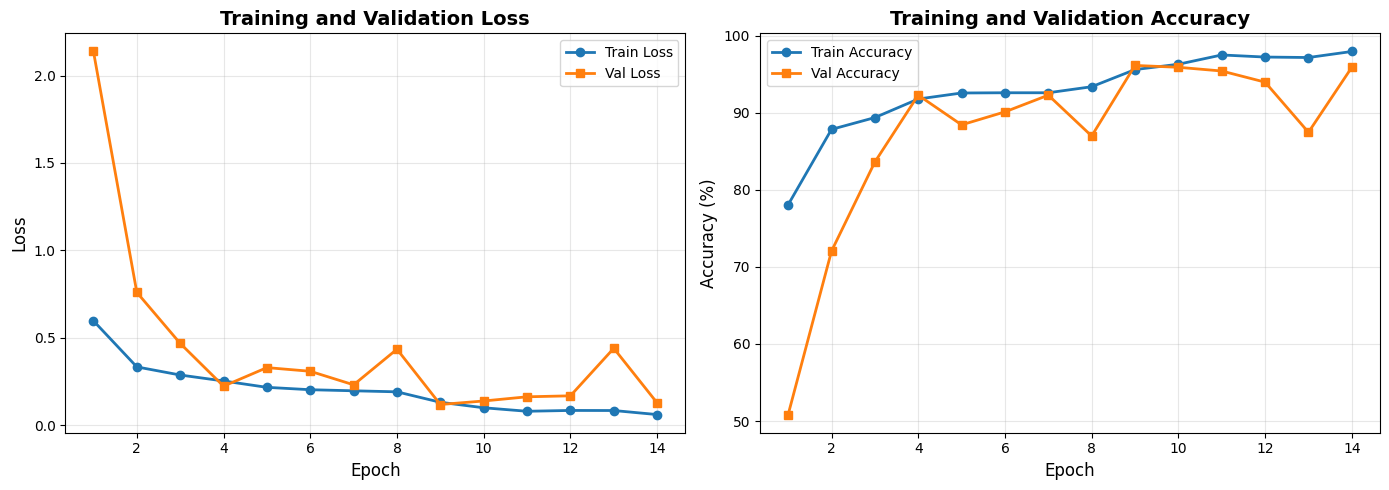

Best Validation Accuracy: 96.14%


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', marker='o', linewidth=2)
ax1.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss', marker='s', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(range(1, len(train_accs)+1), train_accs, label='Train Accuracy', marker='o', linewidth=2)
ax2.plot(range(1, len(val_accs)+1), val_accs, label='Val Accuracy', marker='s', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

In [27]:
model.load_state_dict(torch.load('best_fastvit_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Evaluation completed on test set")

Evaluation completed on test set


In [28]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(all_labels, all_preds)

print("="*60)
print("FINAL MODEL PERFORMANCE")
print("="*60)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print("="*60)

FINAL MODEL PERFORMANCE
Test Accuracy: 94.95%
Best Validation Accuracy: 96.14%


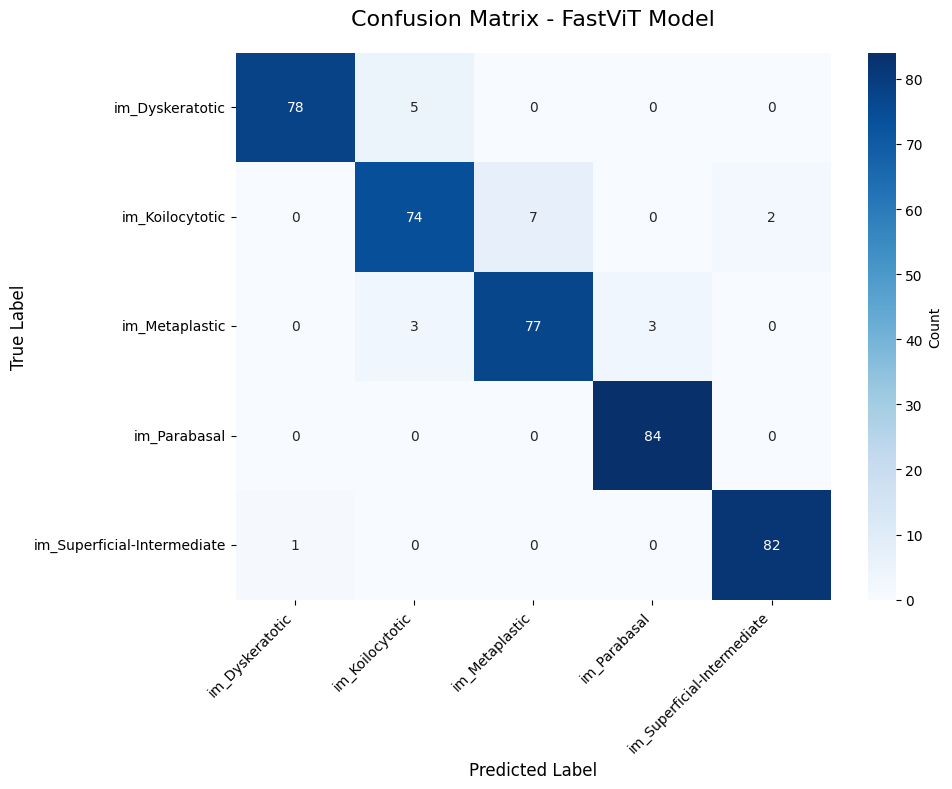

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - FastViT Model', fontsize=16, pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

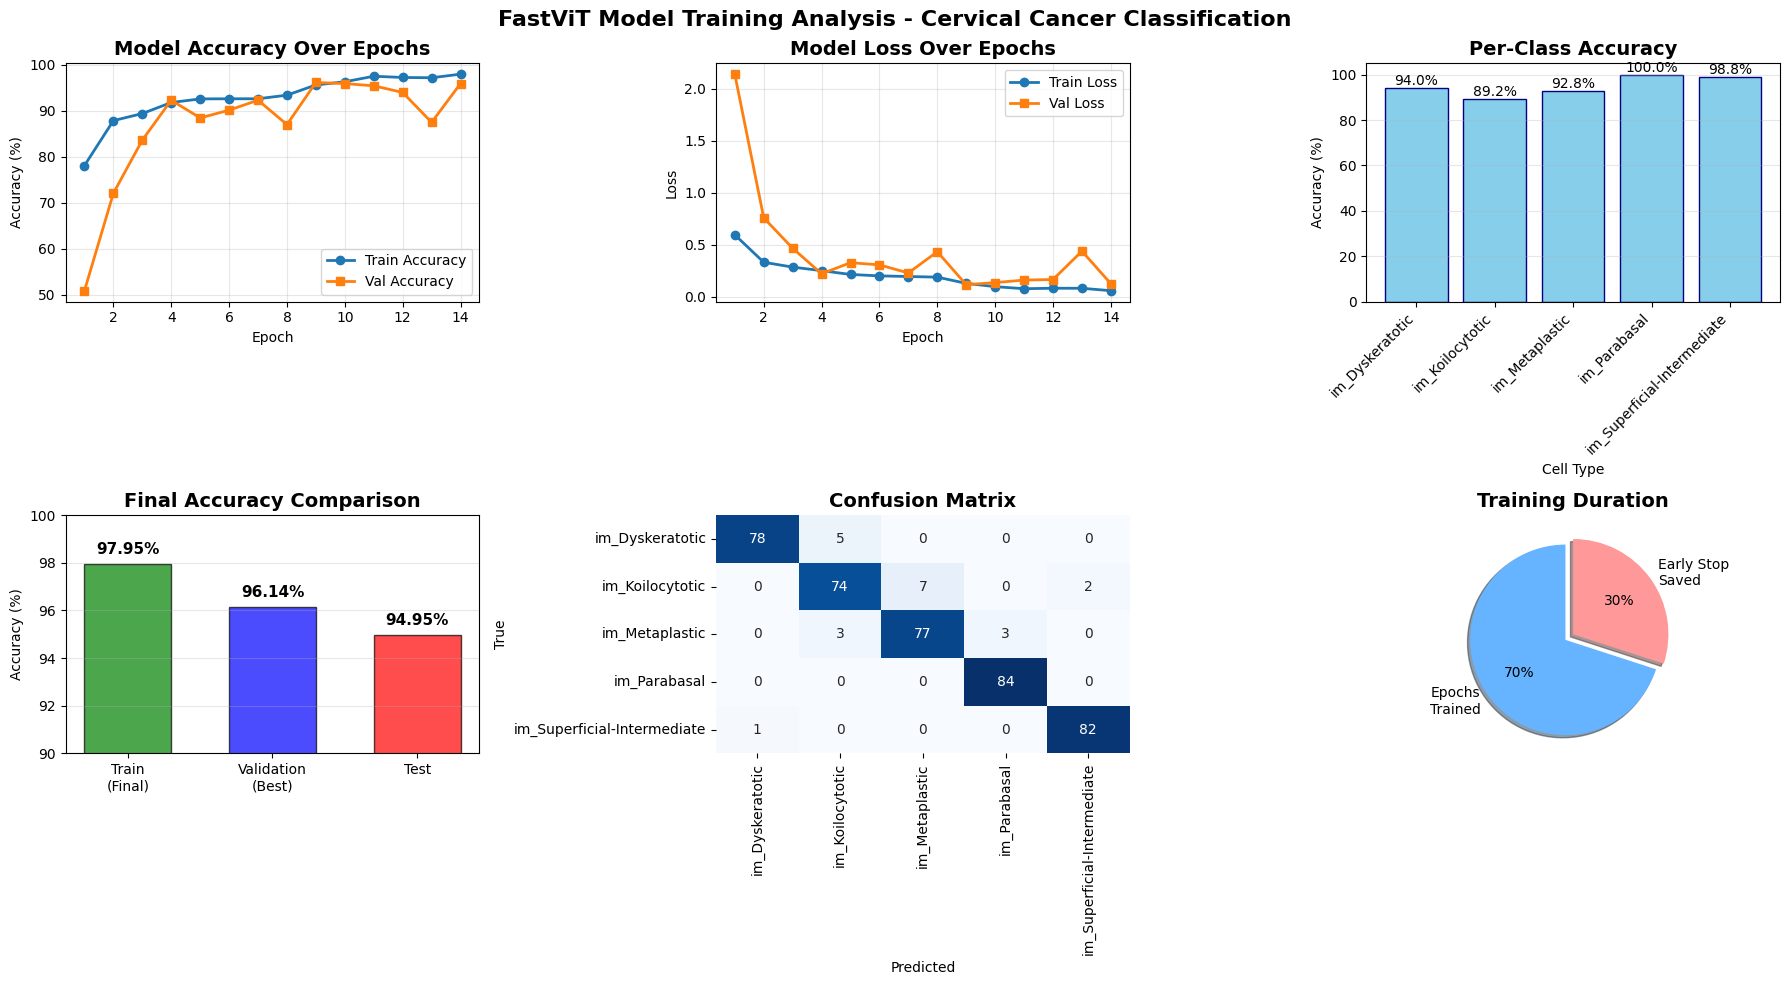


Accuracy Summary:
Training Accuracy (Final): 97.95%
Validation Accuracy (Best): 96.14%
Test Accuracy: 94.95%


In [30]:
fig = plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.plot(range(1, len(train_accs)+1), train_accs, label='Train Accuracy', linewidth=2, marker='o')
plt.plot(range(1, len(val_accs)+1), val_accs, label='Val Accuracy', linewidth=2, marker='s')
plt.title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', linewidth=2, marker='o')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss', linewidth=2, marker='s')
plt.title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
class_accuracy = cm.diagonal() / cm.sum(axis=1)
bars = plt.bar(class_names, class_accuracy * 100, color='skyblue', edgecolor='navy')
plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Cell Type')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(2, 3, 4)
train_acc_final = train_accs[-1]
val_acc_best = best_val_acc
test_acc_final = test_accuracy * 100
categories = ['Train\n(Final)', 'Validation\n(Best)', 'Test']
accuracies = [train_acc_final, val_acc_best, test_acc_final]
colors = ['green', 'blue', 'red']
bars = plt.bar(categories, accuracies, color=colors, alpha=0.7, edgecolor='black', width=0.6)
plt.title('Final Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim([90, 100])
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(2, 3, 5)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, cbar=False)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(2, 3, 6)
epochs_trained = len(train_losses)
labels = ['Epochs\nTrained', 'Early Stop\nSaved']
sizes = [epochs_trained, num_epochs - epochs_trained]
colors = ['#66b3ff', '#ff9999']
explode = (0.1, 0)
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.0f%%', shadow=True, startangle=90)
plt.title('Training Duration', fontsize=14, fontweight='bold')

plt.suptitle('FastViT Model Training Analysis - Cervical Cancer Classification', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\nAccuracy Summary:")
print(f"Training Accuracy (Final): {train_acc_final:.2f}%")
print(f"Validation Accuracy (Best): {val_acc_best:.2f}%")
print(f"Test Accuracy: {test_acc_final:.2f}%")

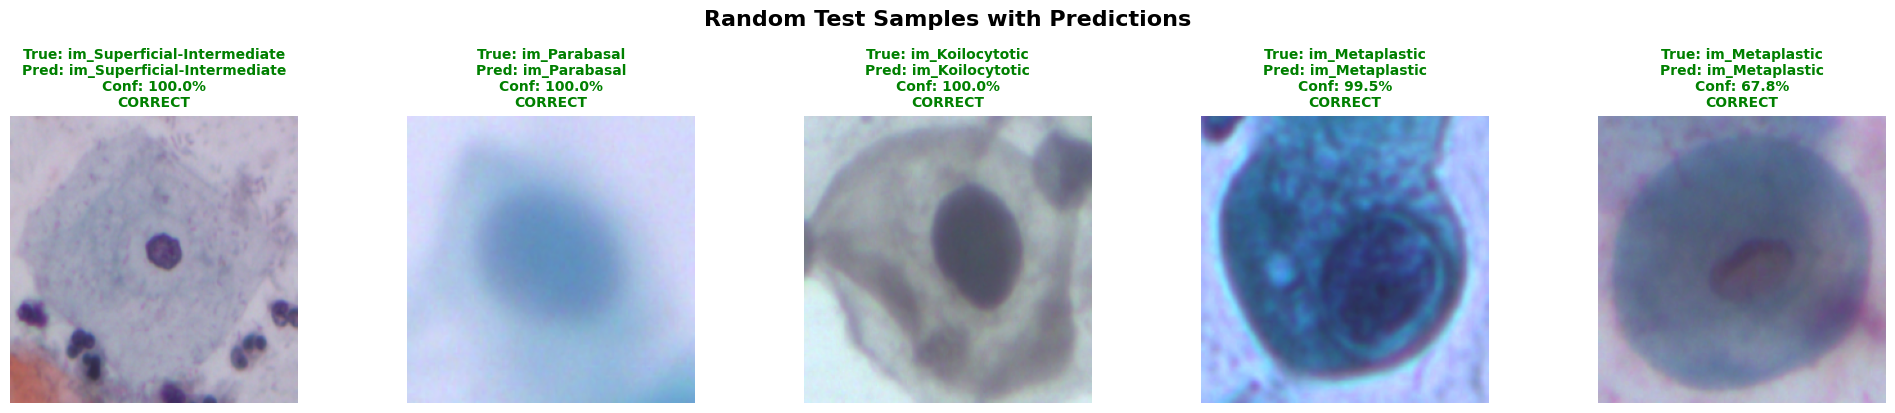

In [31]:
import random

num_samples = 5
random_indices = random.sample(range(len(test_dataset)), num_samples)

fig = plt.figure(figsize=(20, 4))

for i, idx in enumerate(random_indices):
    image, true_label = test_dataset[idx]
    
    image_tensor = image.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image_tensor)
        pred_probs = torch.softmax(output, dim=1)[0].cpu().numpy()
        pred_label = np.argmax(pred_probs)
        confidence = pred_probs[pred_label] * 100
    
    img_display = image.permute(1, 2, 0).cpu().numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)
    
    true_class = class_names[true_label]
    pred_class = class_names[pred_label]
    
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img_display)
    
    if true_label == pred_label:
        color = 'green'
        result = 'CORRECT'
    else:
        color = 'red'
        result = 'WRONG'
    
    title = f'True: {true_class}\nPred: {pred_class}\nConf: {confidence:.1f}%\n{result}'
    plt.title(title, fontsize=10, fontweight='bold', color=color)
    plt.axis('off')

plt.suptitle('Random Test Samples with Predictions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [32]:
!zip -r model.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/best_fastvit_model.pth (deflated 8%)


In [33]:
from IPython.display import FileLink
FileLink(r'model.zip')

/kaggle/working/model.zip